In [1]:
from sklearn.metrics import pairwise_distances, classification_report
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

In [2]:
dataset = 'covertype'
window_size = 48
df = pd.read_csv(f"/root/EdgeCluster/results/{dataset}/tabular/{window_size}/final_clustering.csv")
# df = pd.read_csv("/Users/milenaangelova/git-repo/EdgeCluster/results/retail/retail_0/tabular/6/final_clustering.csv")

# df = pd.read_csv("/Users/milenaangelova/git-repo/EdgeCluster/results/moving/moving_0/tabular/12/final_clustering.csv")

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,cluster,is_included,target,segment,stream,ids
0,0.368684,0.141667,0.045455,0.184681,0.223514,0.071659,0.870079,0.913386,0.582677,0.875366,5,True,5,0,-1,1
1,0.365683,0.155556,0.030303,0.151754,0.215762,0.054798,0.866142,0.925197,0.594488,0.867838,5,True,5,0,-1,2
2,0.472736,0.386111,0.136364,0.191840,0.307494,0.446817,0.921260,0.937008,0.531496,0.853339,2,True,2,0,-1,3
3,0.463232,0.430556,0.272727,0.173228,0.375969,0.434172,0.937008,0.937008,0.480315,0.865886,2,True,2,0,-1,4
4,0.368184,0.125000,0.030303,0.109520,0.222222,0.054939,0.866142,0.921260,0.590551,0.860449,5,True,5,0,-1,5


In [4]:
target = df["target"]
cluster = df["cluster"]
df = df[df.columns[:-6]]

In [5]:
df

,0,1,2,3,4,5,6,7,8,9
0,0.368684,0.141667,0.045455,0.184681,0.223514,0.071659,0.870079,0.913386,0.582677,0.875366
1,0.365683,0.155556,0.030303,0.151754,0.215762,0.054798,0.866142,0.925197,0.594488,0.867838
2,0.472736,0.386111,0.136364,0.191840,0.307494,0.446817,0.921260,0.937008,0.531496,0.853339
3,0.463232,0.430556,0.272727,0.173228,0.375969,0.434172,0.937008,0.937008,0.480315,0.865886
4,0.368184,0.125000,0.030303,0.109520,0.222222,0.054939,0.866142,0.921260,0.590551,0.860449
...,...,...,...,...,...,...,...,...,...,...
581007,0.268634,0.425000,0.303030,0.060845,0.245478,0.015175,0.944882,0.933071,0.464567,0.116688
581008,0.266133,0.422222,0.287879,0.047960,0.239018,0.013348,0.944882,0.933071,0.468504,0.117803
581009,0.263632,0.441667,0.257576,0.042949,0.232558,0.012646,0.929134,0.948819,0.511811,0.119058
581010,0.262631,0.472222,0.227273,0.042949,0.229974,0.012646,0.905512,0.964567,0.562992,0.120452


In [6]:
cluster.unique()

array([5, 2, 1, 7, 3, 6, 4])

In [7]:
import itertools

def calculate_distances(data):
    return pairwise_distances(data,data)

def find_nearest_neighbors(sample, neighbors, n_neighbors):
    """Finds the nearest neighbors to the given sample"""
    neighbors = np.delete(neighbors, sample)
    nearest_neibour_indexes = np.argsort(neighbors)[:n_neighbors]
    return nearest_neibour_indexes

def get_connectivity(dataframe, i, j, j_index):
    """Gets the connectivity value from a given dataframe"""
    i_class = dataframe.iloc[i]["cluster"]
    j_class = dataframe.iloc[j]["cluster"]
    state = (0 if i_class == j_class else float(1)/(j_index + 1))
    return state

def connectivity_samples(X, y, n_neighbors, metric=None, distance_matrix=None, **kwds):
    """Calculates the connectivity for each sample in the dataset."""
    dataframe = pd.DataFrame(data=X, index=range(len(X)))
    dataframe["cluster"] = y
    N = len(X)
    
    if distance_matrix is None:
        distance_matrix = pairwise_distances(X, metric=metric, **kwds)
    
    connectivity_list = []
    for i in range(N):
        connectivity_sum = 0
        nearest_neighbors = find_nearest_neighbors(i, distance_matrix[i], n_neighbors)
        for j in range(n_neighbors):
            connectivity_sum += get_connectivity(dataframe, i, nearest_neighbors[j], j)
        connectivity_list.append(connectivity_sum)
    return connectivity_list

def calculate_connectivity(X_train, y_train, columns, n_neighbors, metric=None, distance_matrix=None):
    si_samples = connectivity_samples(X_train, y_train, n_neighbors, metric, distance_matrix)
    dataframe = pd.DataFrame(data=X_train, columns=columns, index=range(0, len(y_train)))
    dataframe["CONN"] = si_samples
    dataframe["cluster"] = y_train
    #sorted_dataframe = dataframe.sort_values(["CONN"], ascending=[True])
    return dataframe

# F1
def f_measure(pred, true):
    value = (2 * len(pred & true)) / (len(true) + len(pred))
    return value

# SI
def calculate_silhouette(data, clusters):
    # distances = calculate_distances(data.to_numpy(copy=True))
    # distances = calculate_distances_improved(data.to_numpy(copy=True))
    return silhouette_score(data, clusters, n_jobs=-1)

In [8]:
def evalutation_report(data, pred_labels, true_labels):
    # distances = calculate_distances_improved(data.to_numpy(copy=True))
    # connectivity = calculate_connectivity(data, 
    #                                     pred_labels,
    #                                     [x for x in range(data.shape[1])],
    #                                     10, distance_matrix=distances)['CONN'].sum()
    
    F1 = f_measure(pred_labels, true_labels)
    if len(pred_labels.unique()) > 1:
        SI = calculate_silhouette(data, pred_labels)
    else:
        SI = None

    return None, F1, SI

In [9]:
connectivity, F1, SI = evalutation_report(data=df, pred_labels=cluster, true_labels=target)

KeyboardInterrupt: 

In [207]:
metrics_df =  pd.DataFrame({
    'connectivity': [connectivity],
    'F1': [F1],
    'SI': [SI]
})
metrics_df.head()

,connectivity,F1,SI
0,3202.308333,1.0,0.186218


**Extrinsic Measures** \
    - Rand Index \
        Rand Index (RI, ARI) measures the similarity between the cluster assignments by making pair-wise comparisons. A higher score signifies higher similarity. \
    - Mutual Information \
        Mutual Information (MI, NMI, AMI) measures the agreement between the cluster assignments. A higher score signifies higher agreement. \
    - V-measure \
        V-measure measures the correctness of the cluster assignments using conditional entropy analysis. A higher score signifies higher correctness. \
    - Fowlkes-Mallows Scores
        Fowlkes-Mallows Scores measure the correctness of the cluster assignments using pairwise precision and recall. A higher score signifies higher correctness. 

**Intrinsic Measures** \
    - Silhouette Coefficient \
        Silhouette Coefficient measures the between-cluster distance against within-cluster distance. A higher score signifies better-defined clusters. \
    - Calinski-Harabasz Index \
        Calinski-Harabasz Index measures the between-cluster dispersion against within-cluster dispersion. A higher score signifies better-defined clusters.
        A higher ratio signifies the cluster is far away from its other clusters and that the cluster is more well-defined.  \
    - Davies-Bouldin Index 
        Davies-Bouldin Index measures the size of clusters against the average distance between clusters. A lower score signifies better-defined clusters.
        A lower score means that the cluster is relatively small compared to the distance to another cluster, hence well-defined.

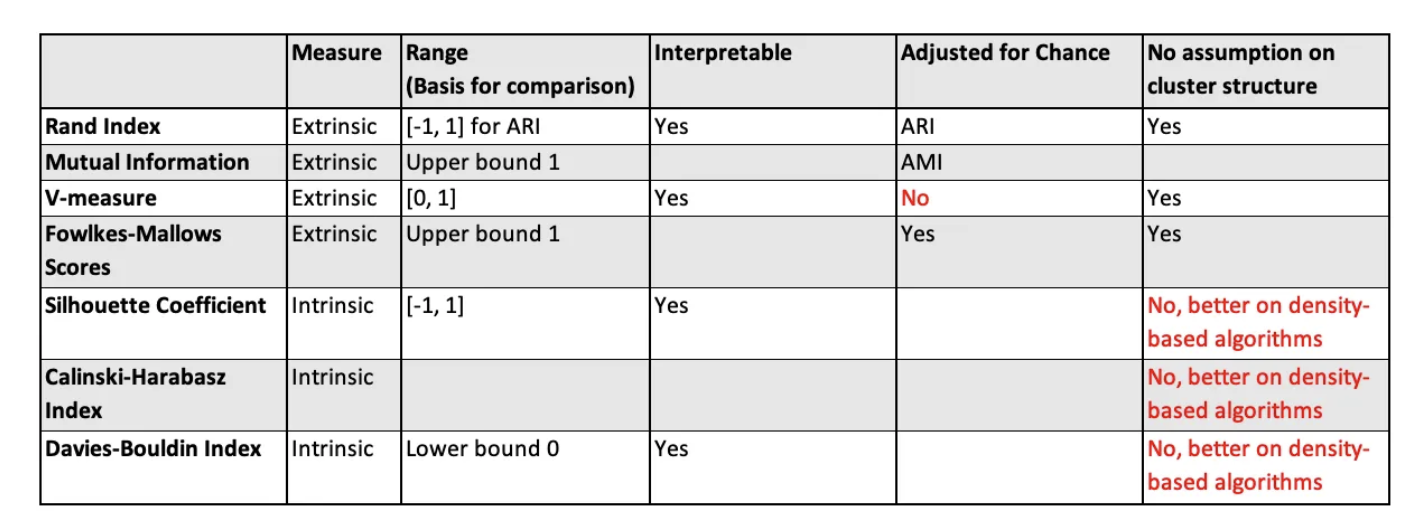